In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [3]:
model = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [7]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

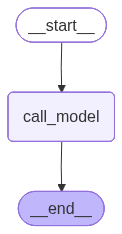

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Tanish."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Tanish.


"Hi Tanish, it's nice to meet you! How can I help you today?"

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 40
Hi, my name is Tanish.
Hi Tanish, it's nice to meet you! How can I help you today?
I am learning LangGraph.


"That's fantastic, Tanish! LangGraph is a really powerful tool for building complex, stateful applications with LLMs. It's a great choice for learning.\n\nWhat are you finding most interesting or challenging about it so far? Are you working on a specific project, or just exploring the core concepts?\n\nI can help you with:\n\n*   **Explaining core concepts:** Nodes, edges, states, `StateGraph`, `END`, `START`, etc.\n*   **Understanding common patterns:** Conditional routing, looping, parallel execution.\n*   **Debugging your code:** If you're running into issues.\n*   **Suggesting next steps or advanced features:** Once you've got the basics down.\n*   **Providing examples:** To illustrate how things work.\n\nJust let me know what's on your mind!"

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM) is a crucial cognitive process that allows us to temporarily hold and manipulate information. Think of it as your brain\'s "scratchpad" or "working memory" for immediate tasks. It\'s where you keep information "on the line" for a brief period, enabling you to process and act on it.\n\nHere\'s a breakdown of its key characteristics and functions:\n\n**Key Characteristics of Short-Term Memory:**\n\n*   **Limited Capacity:** This is one of the most defining features of STM. It can only hold a relatively small amount of information at any given time. The classic estimate, often attributed to George Miller, is around **7 plus or minus 2 items** (chunks of information). However, more recent research suggests this capacity might be even smaller, perhaps closer to 3-4 chunks.\n    *   **What is a "chunk"?** A chunk isn\'t just a single item. It\'s a meaningful unit of information. For example, "FBI" is one chunk, even though it represents three letters. "14921776" is h

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I do not have access to any personal information about you, including your name. I am a large language model, trained by Google.'

In [13]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Tanish.
------------------------------------------------------------------------------------------------------------------------
Hi Tanish, it's nice to meet you! How can I help you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's fantastic, Tanish! LangGraph is a really powerful tool for building complex, stateful applications with LLMs. It's a great choice for learning.

What are you finding most interesting or challenging about it so far? Are you working on a specific project, or just exploring the core concepts?

I can help you with:

*   **Explaining core concepts:** Nodes, edges, states, `StateGraph`, `END`, `START`, etc.
*   **Understanding common patterns:** Conditional routing, looping, parallel execution.
*   **Debugging your code:**